Dataset Info:
Shape: (63, 5)
Columns: ['UserId', 'UsageDuraiton', 'Age', 'Country', 'TotalLikes']

First 5 rows:
   UserId  UsageDuraiton  Age       Country  TotalLikes
0       1              2   55        Turkey           5
1       2              6   45        Canada          10
2       3              3   50       Ireland           7
3       4              4   35  South Africa           5
4       5              1   58        Turkey           2

Missing values:
UserId           0
UsageDuraiton    0
Age              0
Country          0
TotalLikes       0
dtype: int64

Summary Statistics:
          UserId  UsageDuraiton        Age  TotalLikes
count  63.000000      63.000000  63.000000   63.000000
mean   31.761905       4.000000  33.777778    5.317460
std    18.015866       2.879292  15.540213    6.135106
min     1.000000       1.000000  18.000000    0.000000
25%    16.500000       2.000000  19.000000    1.500000
50%    32.000000       3.000000  26.000000    4.000000
75%    47.500000    

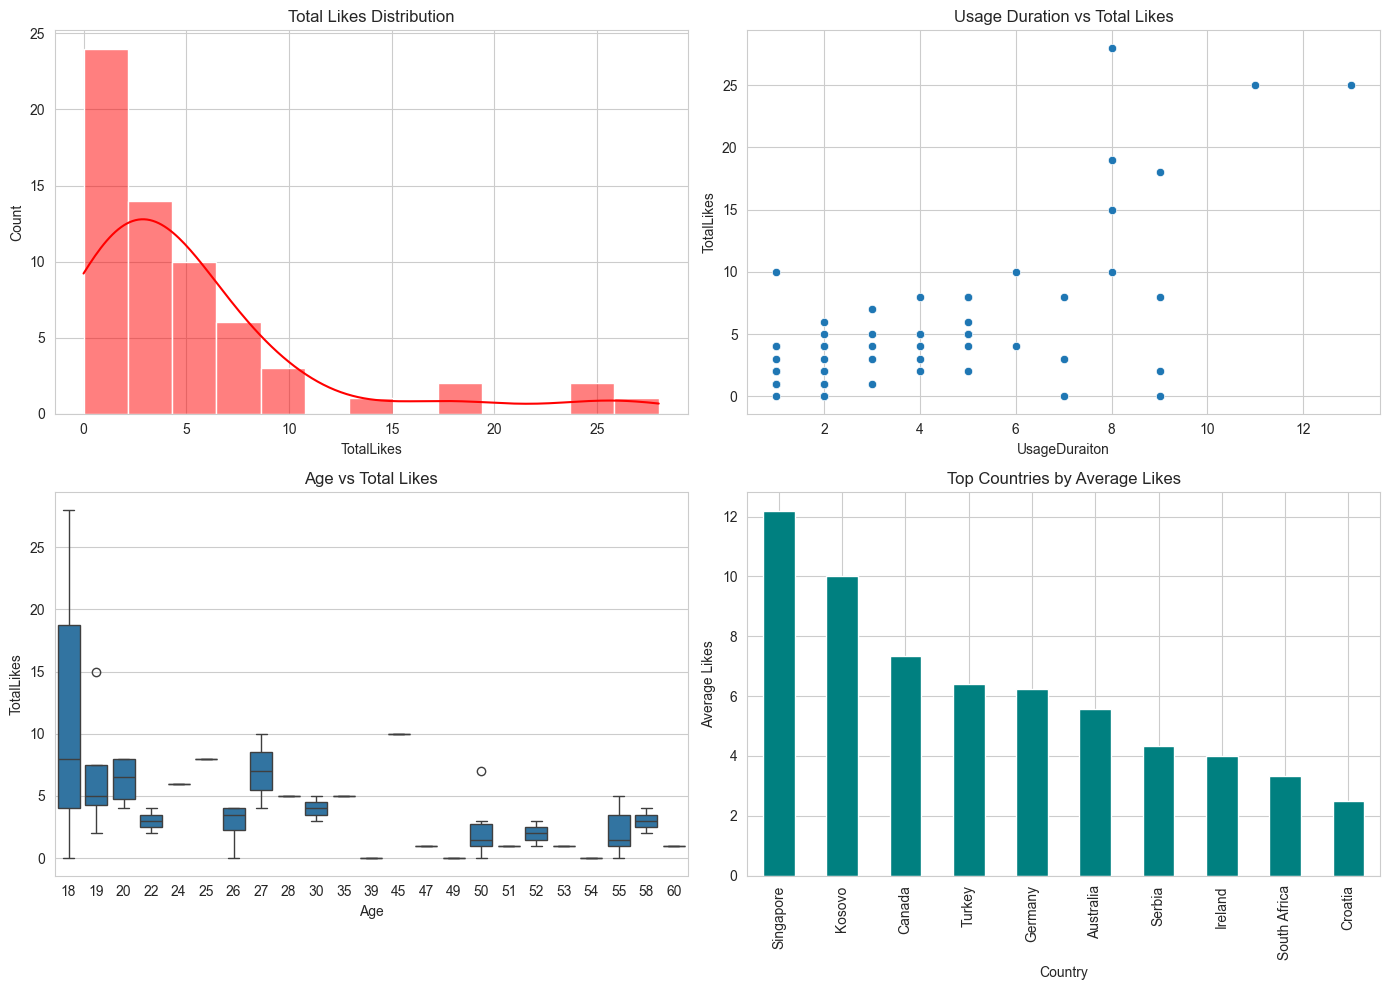

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load and explore data
def load_and_explore_social(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()

    print("Dataset Info:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nMissing values:")
    print(df.isnull().sum())

    return df

# Social media analysis
def analyze_social_media(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    summary_stats = df[numeric_cols].describe()

    country_likes = df.groupby('Country')['TotalLikes'].mean().sort_values(ascending=False)
    age_likes = df.groupby('Age')['TotalLikes'].mean().sort_values(ascending=False)
    top_users = df.sort_values(by='TotalLikes', ascending=False).head(10)
    usage_likes_corr = df[['UsageDuraiton', 'TotalLikes']].corr().iloc[0, 1]

    return summary_stats, country_likes, age_likes, top_users, usage_likes_corr

# Visualization
def plot_social_insights(df, country_likes):
    plt.figure(figsize=(14, 10))

    plt.subplot(2, 2, 1)
    sns.histplot(df['TotalLikes'], kde=True, color='red')
    plt.title('Total Likes Distribution')

    plt.subplot(2, 2, 2)
    sns.scatterplot(data=df, x='UsageDuraiton', y='TotalLikes')
    plt.title('Usage Duration vs Total Likes')

    plt.subplot(2, 2, 3)
    sns.boxplot(data=df, x='Age', y='TotalLikes')
    plt.title('Age vs Total Likes')

    plt.subplot(2, 2, 4)
    country_likes.head(10).plot(kind='bar', color='teal')
    plt.title('Top Countries by Average Likes')
    plt.xlabel('Country')
    plt.ylabel('Average Likes')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    df = load_and_explore_social(r"C:\Users\Dell\Desktop\Task2\social-media.csv")
    summary_stats, country_likes, age_likes, top_users, usage_likes_corr = analyze_social_media(df)

    print("\nSummary Statistics:")
    print(summary_stats)

    print("\nUsage Duration and Likes Correlation:")
    print(usage_likes_corr)

    print("\nTop Users by Likes:")
    print(top_users)

    plot_social_insights(df, country_likes)


# Social Media Analysis Report

## Objective
The objective of this project is to analyze user behavior and engagement patterns on social media.

## Dataset Features
- UserId
- UsageDuraiton
- Age
- Country
- TotalLikes

## Analysis Performed
- Summary statistics of numeric fields
- Average likes by country
- Average likes by age
- Top users by likes
- Correlation between usage duration and likes

## Key Insights
- Usage duration may influence engagement.
- Country-level analysis helps compare user interaction patterns.
- Age-based analysis helps identify engagement differences across age groups.
- Top-user analysis identifies the highest-performing accounts.
- Distribution plots help explain like activity spread.

## Conclusion
This project demonstrates social media behavior analysis using descriptive statistics, grouping, and correlation analysis.
